In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [29]:
#Objectives of notebook
'''
y = mx + b
-make preditions
-compute loss
-compute gradients
-update with w and b
repeat
'''

'\ny = mx + b\n-make preditions\n-compute loss\n-compute gradients\n-update with w and b\nrepeat\n'

In [30]:
#Loading in Data Set
data = pd.read_csv('data/salary_data.csv')

In [31]:
#Splitting into respective training sets
x_train = data['YearsExperience'].values
y_train = data['Salary'].values

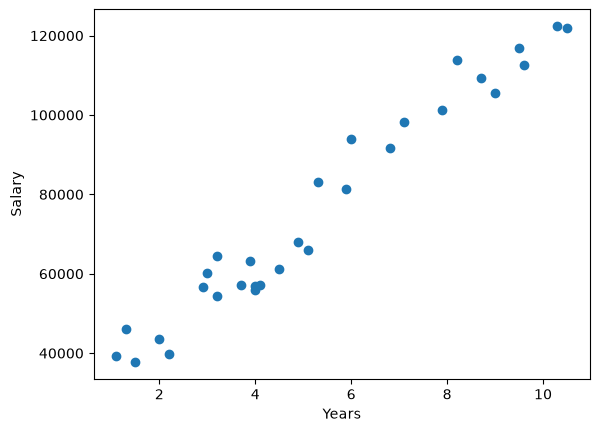

In [32]:
plt.scatter(x_train, y_train)
plt.xlabel('Years')
plt.ylabel('Salary')
plt.show()

In [33]:
#Implentation Requirements
'''
1. Loss Function - Mean Squared Error
2. Gradient Function to compute derivatives of Loss Function
3. Gradient Descent Function
4. Update with w and b
'''

'\n1. Loss Function - Mean Squared Error\n2. Gradient Function to compute derivatives of Loss Function\n3. Gradient Descent Function\n4. Update with w and b\n'

In [34]:
def lossFunction(x, y, w, b):
    m = len(x)
    y_pred = (w * x) + b
    sumOfSquares = 0
    for i in range(m):
        sumOfSquares += (y_pred[i] - y[i]) ** 2

    loss = sumOfSquares / (2 * m)
    return loss

In [35]:
def gradientFunction(x,y,w,b):
    m = len(x)
    dl_dw = 0
    dl_db = 0
    y_pred = (w * x) + b

    for i in range(m):
        dl_dw += (y_pred[i] - y[i]) * x[i]
        dl_db += (y_pred[i] - y[i])

    dl_dw = (dl_dw / m)
    dl_db = (dl_db / m)
    return dl_dw, dl_db

In [51]:
def gradientDescent(x,y, alpha, iterations):
    w = 0
    b = 0
    best_loss = float("inf")
    no_improvements = 0
    for i in range(iterations):
        dl_dw, dl_db = gradientFunction(x,y,w,b)
        w -= alpha * dl_dw
        b -= alpha * dl_db
        loss = lossFunction(x,y,w,b)


        print(f'Iteration {i}: weight is {w}, bias is {b} and loss is {lossFunction(x,y,w,b)}')

        if loss < best_loss - 1e-2:
            best_loss = loss
            no_improvements = 0
        else:
            no_improvements += 1

        if no_improvements >= 5:
            print(f'No improvement for loss function after 5 more iterations stopping after {i}')
            break



    return w, b

In [52]:
learning_rate = 0.01
iterations = 100000
final_w, final_b = gradientDescent(x_train, y_train, learning_rate, iterations)

Iteration 0: weight is 4773.987, bias is 760.03 and loss is 1344612525.8413548
Iteration 1: weight is 7788.160088166667, bias is 1258.8018573999998 and loss is 582933639.1249903
Iteration 2: weight is 9690.227091055453, bias is 1592.4329328080776 and loss is 278595825.9816312
Iteration 3: weight is 10889.506030597111, bias is 1821.6645373752503 and loss is 156901936.81054005
Iteration 4: weight is 11644.664832824514, bias is 1984.882138242438 and loss is 108149191.53202362
Iteration 5: weight is 12119.168311256937, bias is 2106.3434587426045 and loss is 88526795.5063979
Iteration 6: weight is 12416.317808711374, bias is 2201.3782145503933 and loss is 80538511.12387824
Iteration 7: weight is 12601.394448807383, bias is 2279.674079502025 and loss is 77197055.8093798
Iteration 8: weight is 12715.65253207105, bias is 2347.353246993706 and loss is 75711992.7100282
Iteration 9: weight is 12785.16264257986, bias is 2408.284709986394 and loss is 74968933.0700283
Iteration 10: weight is 12826.4

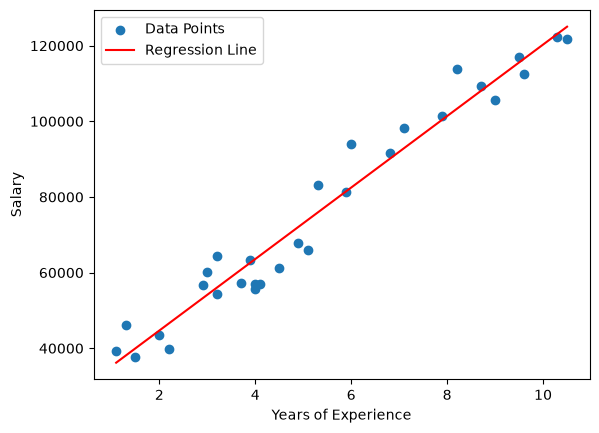

In [54]:
plt.scatter(x_train, y_train, label = 'Data Points')
x_vals = np.linspace(min(x_train), max(x_train), 100)
y_vals = final_w * x_vals + final_b
plt.plot(x_vals, y_vals, color = 'red', label = 'Regression Line')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.legend()
plt.show()